# 01 — Inspect the EDM4HEP collider dataset

This notebook inspects `clean_data_ecm240.root` before building the masked-particle Transformer.

We will:
1. open the ROOT file;
2. inspect the `events` tree;
3. read the `Particle` collection;
4. select generator-level final-state particles (`generatorStatus == 1`);
5. measure particle multiplicity;
6. plot basic kinematic and PDG distributions.

**Important:** this notebook deliberately starts with the MC `Particle` collection. We will keep `reco_clean` for a later comparison.

In [1]:
# If these imports fail on SWAN, install/load the corresponding Python packages there.
import numpy as np
import awkward as ak
import uproot
import matplotlib.pyplot as plt

print("NumPy:", np.__version__)
print("Awkward:", ak.__version__)
print("Uproot:", uproot.__version__)

NumPy: 2.4.4
Awkward: 2.9.0
Uproot: 5.7.1


In [2]:
# Change this only if your ROOT file is in a different directory.
FILE = "clean_data_ecm240.root"

root_file = uproot.open(FILE)
print(root_file.keys())

events = root_file["events"]
print(events)
print("Number of events:", events.num_entries)

['events;1', 'eventsProcessed;1']
<TTree 'events' (10 branches) at 0x7f5ace21c440>
Number of events: 45830


In [3]:
# Inspect branch names.
for name in events.keys():
    if name.startswith("Particle"):
        print(name)

Particle
Particle/Particle.PDG
Particle/Particle.generatorStatus
Particle/Particle.simulatorStatus
Particle/Particle.charge
Particle/Particle.time
Particle/Particle.mass
Particle/Particle.vertex.x
Particle/Particle.vertex.y
Particle/Particle.vertex.z
Particle/Particle.endpoint.x
Particle/Particle.endpoint.y
Particle/Particle.endpoint.z
Particle/Particle.momentum.x
Particle/Particle.momentum.y
Particle/Particle.momentum.z
Particle/Particle.momentumAtEndpoint.x
Particle/Particle.momentumAtEndpoint.y
Particle/Particle.momentumAtEndpoint.z
Particle/Particle.spin.x
Particle/Particle.spin.y
Particle/Particle.spin.z
Particle/Particle.colorFlow.a
Particle/Particle.colorFlow.b
Particle/Particle.parents_begin
Particle/Particle.parents_end
Particle/Particle.daughters_begin
Particle/Particle.daughters_end


In [4]:
# Read the particle-level branches.
# These are jagged arrays: each event can contain a different number of particles.
particle = events.arrays(
    [
        "Particle.PDG",
        "Particle.generatorStatus",
        "Particle.charge",
        "Particle.mass",
        "Particle.momentum.x",
        "Particle.momentum.y",
        "Particle.momentum.z",
    ],
    library="ak",
)

print(particle.fields)
print("First event PDGs:", particle["Particle.PDG"][0])
print("First event statuses:", particle["Particle.generatorStatus"][0])

['Particle.PDG', 'Particle.generatorStatus', 'Particle.charge', 'Particle.mass', 'Particle.momentum.x', 'Particle.momentum.y', 'Particle.momentum.z']
First event PDGs: [11, -11, 11, -11, -24, 24, 11, -11, -24, ..., 22, 22, 22, 22, 22, 22, 22, 22]
First event statuses: [4, 4, 21, 21, 22, 22, 42, 41, 44, 44, 1, ..., 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1]


In [5]:
# Select generator-level final-state particles.
final_mask = particle["Particle.generatorStatus"] == 1

final_pdg = particle["Particle.PDG"][final_mask]
final_charge = particle["Particle.charge"][final_mask]
final_mass = particle["Particle.mass"][final_mask]
final_px = particle["Particle.momentum.x"][final_mask]
final_py = particle["Particle.momentum.y"][final_mask]
final_pz = particle["Particle.momentum.z"][final_mask]

multiplicity = ak.to_numpy(ak.num(final_pdg, axis=1))

print("Final-state multiplicity statistics")
print("  min   :", multiplicity.min())
print("  max   :", multiplicity.max())
print("  mean  :", multiplicity.mean())
print("  median:", np.median(multiplicity))


Final-state multiplicity statistics
  min   : 35
  max   : 175
  mean  : 82.35852061968143
  median: 81.0


In [6]:
# Convert momentum components to useful collider variables.
pt = np.sqrt(final_px**2 + final_py**2)
phi = np.arctan2(final_py, final_px)

# Energy from the mass-shell relation.
energy = np.sqrt(final_px**2 + final_py**2 + final_pz**2 + final_mass**2)

# eta = asinh(pz / pT). Keep missing values where pT == 0.
eta = ak.mask(np.arcsinh(final_pz / pt), pt > 0)

print("First event pT :", pt[0])
print("First event eta:", eta[0])
print("First event phi:", phi[0])


First event pT : [0.0335, 0, 0, 8.12, 2.77, 1.11, ..., 0.0762, 0.232, 0.289, 0.0657, 5.82, 4.67]
First event eta: [-5.46, None, None, -2.34, -2.31, ..., -0.0121, 0.0573, 0.732, 0.486, 0.506]
First event phi: [-1.85, 0, 0, -2.37, -2.35, 1.93, ..., 0.994, 0.695, 1.41, 0.495, 0.511]


/cvmfs/sft.cern.ch/lcg/views/LCG_110_cuda/x86_64-el9-gcc13-opt/lib/python3.13/site-packages/awkward/_nplikes/array_module.py:289: RuntimeWarning: divide by zero encountered in divide
  return impl(*broadcasted_args, **(kwargs or {}))


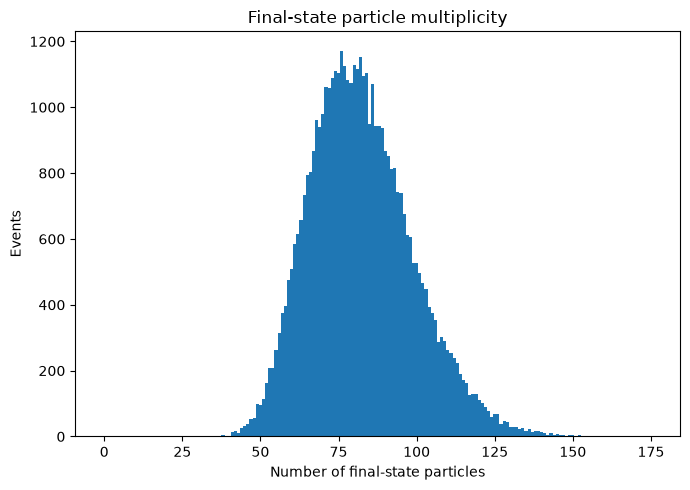

In [7]:
# Plot 1 — final-state particle multiplicity per event.
plt.figure(figsize=(7, 5))
plt.hist(multiplicity, bins=np.arange(multiplicity.max() + 2) - 0.5)
plt.xlabel("Number of final-state particles")
plt.ylabel("Events")
plt.title("Final-state particle multiplicity")
plt.tight_layout()
plt.show()

In [8]:
# Flatten jagged arrays for particle-level distributions.
pt_flat = ak.to_numpy(ak.flatten(pt, axis=1))
phi_flat = ak.to_numpy(ak.flatten(phi, axis=1))
pdg_flat = ak.to_numpy(ak.flatten(final_pdg, axis=1))

# eta contains masked values when pT=0, so remove missing values.
eta_flat = ak.to_numpy(ak.flatten(ak.drop_none(eta), axis=1))

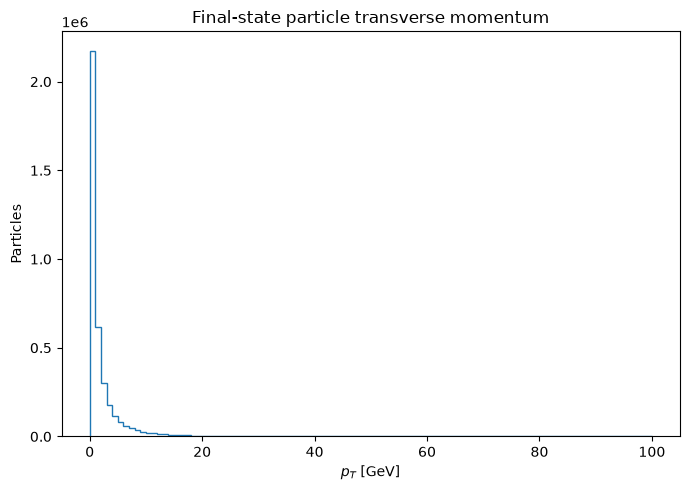

In [9]:
# Plot 2 — pT.
plt.figure(figsize=(7, 5))
plt.hist(pt_flat, bins=100, range=(0, 100), histtype="step")
plt.xlabel(r"$p_T$ [GeV]")
plt.ylabel("Particles")
plt.title("Final-state particle transverse momentum")
plt.tight_layout()
plt.show()

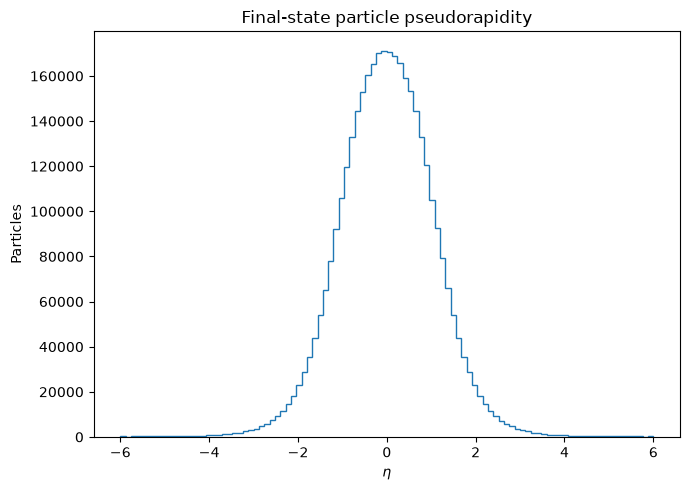

In [10]:
# Plot 3 — eta.
plt.figure(figsize=(7, 5))
plt.hist(eta_flat, bins=100, range=(-6, 6), histtype="step")
plt.xlabel(r"$\eta$")
plt.ylabel("Particles")
plt.title("Final-state particle pseudorapidity")
plt.tight_layout()
plt.show()

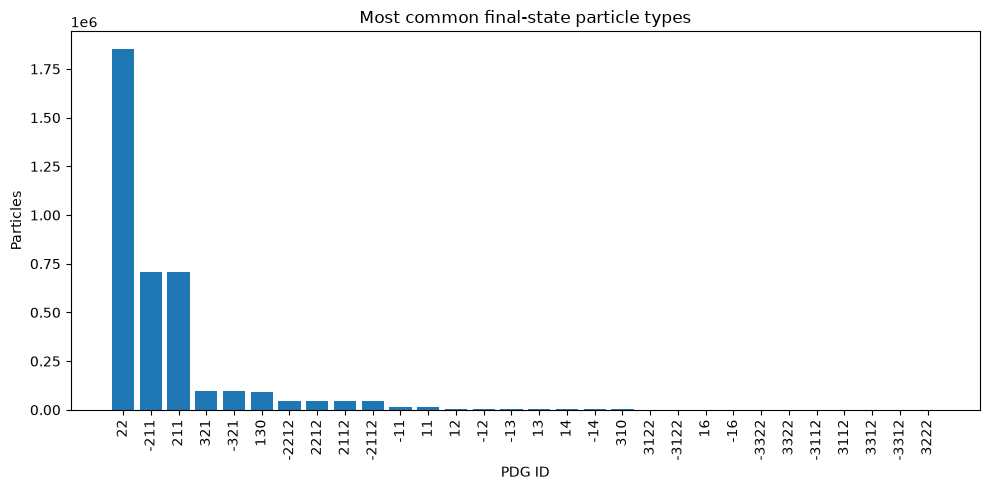

Most common PDGs:
PDG     22: 1850622
PDG   -211: 705895
PDG    211: 705716
PDG    321: 94861
PDG   -321: 94677
PDG    130: 93004
PDG  -2212: 46282
PDG   2212: 46217
PDG   2112: 45681
PDG  -2112: 45648
PDG    -11: 13111
PDG     11: 13103
PDG     12: 2652
PDG    -12: 2644
PDG    -13: 2604
PDG     13: 2553
PDG     14: 2534
PDG    -14: 2483
PDG    310: 1842
PDG   3122: 703
PDG  -3122: 674
PDG     16: 346
PDG    -16: 346
PDG  -3322: 75
PDG   3322: 75
PDG  -3112: 37
PDG   3112: 35
PDG   3312: 28
PDG  -3312: 25
PDG   3222: 10


In [11]:
# Plot 4 — PDG IDs.
unique_pdg, counts = np.unique(pdg_flat, return_counts=True)
order = np.argsort(counts)[::-1][:30]

plt.figure(figsize=(10, 5))
plt.bar(unique_pdg[order].astype(str), counts[order])
plt.xticks(rotation=90)
plt.xlabel("PDG ID")
plt.ylabel("Particles")
plt.title("Most common final-state particle types")
plt.tight_layout()
plt.show()

print("Most common PDGs:")
for i in order:
    print(f"PDG {unique_pdg[i]:>6}: {counts[i]}")


## Next decision

After running this notebook, record:
- mean/median/max final-state multiplicity;
- dominant PDG IDs;
- whether the pT/eta distributions look sensible;
- whether there are events with unusually large particle multiplicity.

Those numbers will determine the padding/truncation strategy and the first Transformer configuration in Notebook 03.